# Iteration 1

### Initial Set-up

In [1]:
import pandas as pd
import numpy as np
import gensim
import nltk
import string
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from collections import Counter
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
import pandas as pd
import numpy as np
import gensim
import nltk
import string
import textstat
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from collections import Counter
from gensim.models import KeyedVectors
from scipy.sparse import hstack
from sklearn.preprocessing import MinMaxScaler
import ast
from scipy.sparse import hstack


print("Libraries imported successfully.")

Libraries imported successfully.


# Iteration 1: Evaluating Different Datasets

## Go_emotions Raw Dataset

In [2]:
# File path
data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\task 4 - Feature Extraction\data\data_raw.csv"

# Load the dataset
df = pd.read_csv(data_path)

# Display the first few rows to check if data is loaded correctly
print("Step 1: Dataset loaded successfully. Preview:")
display(df.head())

Step 1: Dataset loaded successfully. Preview:


,Unnamed: 0,text,happy,sad,disgusted,mad,scared,surprised,neutral
0,0,That game hurt.,0,1,0,0,0,0,0
1,2,"You do right, if you don't care then fuck 'em!",0,0,0,0,0,0,1
2,3,Man I love reddit.,1,0,0,0,0,0,0
3,4,"[NAME] was nowhere near them, he was by the Fa...",0,0,0,0,0,0,1
4,5,Right? Considering it’s such an important docu...,1,0,0,0,0,0,0


In [3]:
# Convert one-hot encoded labels into categorical labels
emotion_cols = ['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral']
df['emotion_label'] = df[emotion_cols].idxmax(axis=1)  # Convert one-hot to category names

# Encode categorical labels as integers
label_encoder = LabelEncoder()
df['emotion_label_encoded'] = label_encoder.fit_transform(df['emotion_label'])  

# Display the first few rows to verify the conversion
print("Step 2: Converted one-hot labels into categorical labels. Preview:")
df[['text', 'emotion_label', 'emotion_label_encoded']].head()

Step 2: Converted one-hot labels into categorical labels. Preview:


,text,emotion_label,emotion_label_encoded
0,That game hurt.,sad,4
1,"You do right, if you don't care then fuck 'em!",neutral,3
2,Man I love reddit.,happy,1
3,"[NAME] was nowhere near them, he was by the Fa...",neutral,3
4,Right? Considering it’s such an important docu...,happy,1


In [4]:
# Check for missing values in 'text' column
missing_values = df['text'].isna().sum()

# Display number of missing values
print(f"Number of missing rows in 'text' column: {missing_values}")

# Remove rows with missing text values
df_cleaned = df.dropna(subset=['text']) 

# Display result after removal
print(f"Step 3: Removing missing columns completed. Number of rows after removing missing text: {df_cleaned.shape[0]}")

Number of missing rows in 'text' column: 0
Step 3: Removing missing columns completed. Number of rows after removing missing text: 171820


In [5]:
# Split data into training, validation, and testing sets (before vectorization to avoid data leakage)
X_train, X_temp, y_train, y_temp = train_test_split(
    df_cleaned['text'].astype(str),  # Text
    df_cleaned['emotion_label_encoded'],  # Labels
    test_size=0.3, random_state=42, stratify=df_cleaned['emotion_label_encoded']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Display dataset split details
print(f"Step 4: Data successfully split into training, validation, and testing sets.")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Step 4: Data successfully split into training, validation, and testing sets.
Training set size: 120274 samples
Validation set size: 25773 samples
Testing set size: 25773 samples


In [6]:
# Convert text data to TF-IDF features
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')  # Limit vocab size and remove stopwords
X_train_tfidf = vectorizer.fit_transform(X_train)  # Learn vocab from training data
X_val_tfidf = vectorizer.transform(X_val)  # Transform validation data (no fitting)
X_test_tfidf = vectorizer.transform(X_test)  # Transform test data (no fitting)

# Display feature shapes
print(f"Step 5: TF-IDF transformation completed. Feature shape (train): {X_train_tfidf.shape}")
print(f"Feature shape (validation): {X_val_tfidf.shape}")
print(f"Feature shape (test): {X_test_tfidf.shape}")

Step 5: TF-IDF transformation completed. Feature shape (train): (120274, 10000)
Feature shape (validation): (25773, 10000)
Feature shape (test): (25773, 10000)


In [7]:
# Initialize and train the Naïve Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

print("Step 6: Naïve Bayes model trained successfully.")

Step 6: Naïve Bayes model trained successfully.


In [8]:
# Make predictions on the validation and test sets
y_val_pred = nb_model.predict(X_val_tfidf)
y_test_pred = nb_model.predict(X_test_tfidf)

print("Step 7: Model prediction completed for validation and test sets.")

Step 7: Model prediction completed for validation and test sets.


In [9]:
# Generate classification report for validation set
val_report = classification_report(y_val, y_val_pred, target_names=label_encoder.classes_, zero_division=1)
val_accuracy = accuracy_score(y_val, y_val_pred)

print("Step 8: Validation Set Evaluation Completed.")
print(f"Validation Accuracy: {val_accuracy:.2f}")
print("Validation Classification Report:\n", val_report)

# Generate classification report for test set
test_report = classification_report(y_test, y_test_pred, target_names=label_encoder.classes_, zero_division=1)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Step 8: Test Set Evaluation Completed.")
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Test Classification Report:\n", test_report)

Step 8: Validation Set Evaluation Completed.
Validation Accuracy: 0.48
Validation Classification Report:
               precision    recall  f1-score   support

   disgusted       0.75      0.02      0.04       437
       happy       0.54      0.74      0.62      9728
         mad       0.49      0.13      0.21      3399
     neutral       0.42      0.56      0.48      8295
         sad       0.66      0.08      0.14      1559
      scared       0.89      0.02      0.04       386
   surprised       0.47      0.02      0.04      1969

    accuracy                           0.48     25773
   macro avg       0.60      0.22      0.22     25773
weighted avg       0.50      0.48      0.43     25773

Step 8: Test Set Evaluation Completed.
Test Accuracy: 0.48
Test Classification Report:
               precision    recall  f1-score   support

   disgusted       0.80      0.02      0.04       437
       happy       0.53      0.75      0.62      9728
         mad       0.49      0.13      0.21   

Step 9: Confusion Matrix for Validation Set
Step 9: Confusion Matrix for Test Set


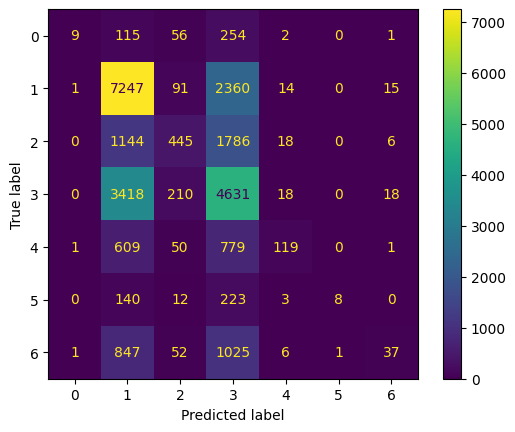

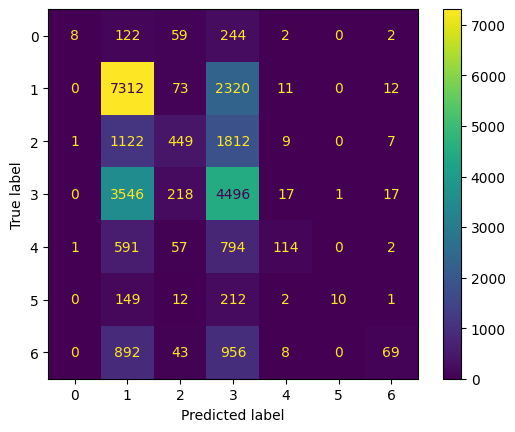

In [10]:
# Display Confusion Matrix for both Validation and Test Sets
print("Step 9: Confusion Matrix for Validation Set")
ConfusionMatrixDisplay.from_estimator(nb_model, X_val_tfidf, y_val)

print("Step 9: Confusion Matrix for Test Set")
ConfusionMatrixDisplay.from_estimator(nb_model, X_test_tfidf, y_test)

Step 10: Plot the Learning Curve


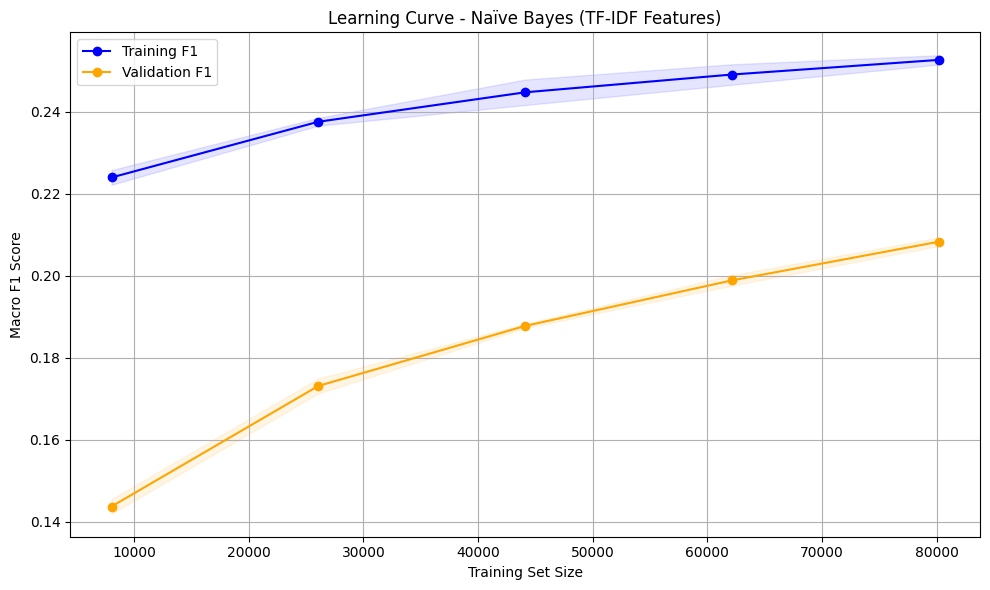

In [11]:
from sklearn.model_selection import learning_curve

# Learning Curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=nb_model,
    X=X_train_tfidf,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# Calculate means and standard deviations
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

# Plotting the learning curve
print("Step 10: Plot the Learning Curve")
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores_mean, 'o-', label="Training F1", color="blue")
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="blue")
plt.plot(train_sizes, val_scores_mean, 'o-', label="Validation F1", color="orange")
plt.fill_between(train_sizes, val_scores_mean - val_scores_std, val_scores_mean + val_scores_std, alpha=0.1, color="orange")
plt.title("Learning Curve - Naïve Bayes (TF-IDF Features)")
plt.xlabel("Training Set Size")
plt.ylabel("Macro F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

### Final Testing

In [12]:
# Define the path for the test dataset
test_data_path = r"C:\Users\vikku\OneDrive\Documenten\Buas\2024-25c-fai2-adsai-group-group21\data\raw\test_g21.csv"

# Load the New Test Dataset
df_test = pd.read_csv(test_data_path)

# Display dataset preview
print("New test dataset loaded successfully. Preview:")
display(df_test.head())

# Rename Emotion Columns to Match Training Data
rename_dict = {
    "happiness": "happy",
    "sadness": "sad",
    "disgust": "disgusted",
    "anger": "mad",
    "fear": "scared",
    "surprise": "surprised",
    "neutral": "neutral"
}

df_test = df_test.rename(columns=rename_dict)

# Convert One-Hot Encoded Labels into Categorical Labels
emotion_cols = ['happiness', 'sadness', 'disgust', 'anger', 'fear', 'surprised', 'neutral']

# Convert one-hot labels to categorical emotion names
df_test['emotion_label'] = df_test[emotion_cols].idxmax(axis=1)

# Encode categorical labels using the trained label encoder
df_test['emotion_label_encoded'] = label_encoder.transform(df_test['emotion_label'])

# Display preview after label encoding
print("Converted one-hot labels into categorical labels. Preview:")
display(df_test[['text', 'emotion_label', 'emotion_label_encoded']].head())

# Handle Missing Values (if any)
missing_values = df_test['text'].isna().sum()
if missing_values > 0:
    print(f"Warning: {missing_values} missing rows found in the test dataset. Removing...")
    df_test = df_test.dropna(subset=['text'])
    print(f"Rows after removing missing values: {df_test.shape[0]}")

# Transform Text Data Using TF-IDF (Use Trained Vectorizer)
X_test_new_tfidf = vectorizer.transform(df_test['text'].astype(str))

# Make Predictions Using the Trained Model
y_test_new_pred = nb_model.predict(X_test_new_tfidf)

# Evaluate Model Performance on Test Data
accuracy_new = accuracy_score(df_test['emotion_label_encoded'], y_test_new_pred)
print(f"Test Dataset Accuracy: {accuracy_new:.2f}")

# Generate classification report
print("Classification Report on New Test Data:\n")
print(classification_report(df_test['emotion_label_encoded'], y_test_new_pred, target_names=label_encoder.classes_, zero_division=1))

# Display Confusion Matrix
print("Confusion Matrix for New Test Data:")
ConfusionMatrixDisplay.from_estimator(nb_model, X_test_new_tfidf, df_test['emotion_label_encoded'])

New test dataset loaded successfully. Preview:


,Unnamed: 0,text,emotion,sub-emotion
0,0,Hang on to your seats cuz Asia's Next Top Mode...,happiness,excitement
1,1,Thousands of model hopefuls from all over Asia...,happiness,optimism
2,2,But only the standout modeling talent were cho...,happiness,pride
3,3,Prepare for an adventure of a lifetime,happiness,excitement
4,4,All I can say girls for this fierce fifth seas...,fear,excitement


KeyError: "None of [Index(['happy', 'sad', 'disgusted', 'mad', 'scared', 'surprised', 'neutral'], dtype='object')] are in the [columns]"

Go_emotions Light